# Tonnetz vs Chroma vs PCA — Results Summary

**Research question:** Does the music-theoretic Tonnetz geometry outperform data-driven PCA for chord estimation, and does the answer depend on the harmonic complexity of the target domain?

**Setup:** 8 input representations × 7 cross-domain transfer experiments × 3 corpora (SMT synth, Beatles pop, Schubert classical). CNN architecture and parameter count held constant. PCA fitted per-experiment on training data.

This notebook loads pre-computed results and visualizes them. No training or feature extraction occurs.

In [1]:
import pickle, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Patch
from sklearn.metrics import f1_score

matplotlib.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.dpi': 150,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'figure.facecolor': 'white',
})

with open('all_experiment_results.pkl', 'rb') as f:
    data = pickle.load(f)

results     = data['results']
exp_e2_res  = data['exp_e2_res']
exp_e3_res  = data['exp_e3_res']
exp_e4_res  = data['exp_e4_res']
exp_e5_res  = data['exp_e5_res']
exp_e6_res  = data['exp_e6_res']
exp_e7_res  = data['exp_e7_res']
rand_results = data['rand_results']
ref_values   = data['ref_values']

all_experiments = {
    'E1: SMT\u2192Beatles':   results,
    'E2: Beatles\u2192SMT':   exp_e2_res,
    'E3: SMT\u2192Schubert':  exp_e3_res,
    'E4: Schubert\u2192SMT':  exp_e4_res,
    'E5: SMT\u2192AllReal':   exp_e5_res,
    'E6: AllReal\u2192SMT':   exp_e6_res,
    'E7: Mixed holdout':      exp_e7_res,
}

ALL_REP_DIMS = {
    'chroma': 12, 'deep_chroma': 12, 'tonnetz': 6, 'tonnetz_deep': 6,
    'chroma_pca6': 6, 'deep_chroma_pca6': 6,
    'chroma_rand6': 6, 'deep_chroma_rand6': 6,
}

COLORS = {
    'chroma': '#4C72B0', 'deep_chroma': '#55A868',
    'tonnetz': '#DD8452', 'tonnetz_deep': '#C44E52',
    'chroma_pca6': '#9B59B6', 'deep_chroma_pca6': '#1ABC9C',
    'chroma_rand6': '#BDC3C7', 'deep_chroma_rand6': '#7F8C8D',
}

ROOTS = ['C','Cs','D','Ds','E','F','Fs','G','Gs','A','As','B']
QUALITIES = ['maj', 'min']
CHORD_LABELS = [f'{r}:{q}' for r in ROOTS for q in QUALITIES]
IDX2LABEL = {i: l for i, l in enumerate(CHORD_LABELS)}
CONSONANCE_VEC = np.array([0,7,5,1,1,2,3,1,2,2,4,6], dtype=float)

focus_reps = ['deep_chroma_pca6', 'tonnetz_deep', 'deep_chroma', 'tonnetz']
focus_labels = ['PCA-6 (deep)', 'Tonnetz (deep)', 'DeepChroma 12-D', 'Tonnetz (CQT)']

print(f'Loaded {len(all_experiments)} experiments, {len(ALL_REP_DIMS)} representations.')

Loaded 7 experiments, 8 representations.


## Figure 1 — Cross-Experiment Results Table

Macro F1 across all 7 transfer experiments. **Bold** = winner per experiment.

In [2]:
rows = []
for exp_name, exp_res in all_experiments.items():
    row = {'Experiment': exp_name}
    best_rep = max(ALL_REP_DIMS, key=lambda r: exp_res[r]['macro_f1'])
    for rep in ALL_REP_DIMS:
        val = exp_res[rep]['macro_f1']
        row[f'CNN-{rep}'] = val
    row['Best'] = best_rep
    rows.append(row)

df = pd.DataFrame(rows)
print(df.to_string(index=False, float_format='%.3f'))

       Experiment  CNN-chroma  CNN-deep_chroma  CNN-tonnetz  CNN-tonnetz_deep  CNN-chroma_pca6  CNN-deep_chroma_pca6  CNN-chroma_rand6  CNN-deep_chroma_rand6             Best
  E1: SMT→Beatles       0.110            0.256        0.221             0.354            0.171                 0.390             0.133                  0.322 deep_chroma_pca6
  E2: Beatles→SMT       0.088            0.191        0.265             0.721            0.127                 0.551             0.170                  0.524     tonnetz_deep
 E3: SMT→Schubert       0.103            0.112        0.215             0.224            0.201                 0.187             0.135                  0.160     tonnetz_deep
 E4: Schubert→SMT       0.084            0.102        0.412             0.689            0.173                 0.453             0.243                  0.412     tonnetz_deep
  E5: SMT→AllReal       0.110            0.201        0.234             0.311            0.200                 0.290         

## Figure 2 — Rank Stability Across Experiments (Macro F1 / TWE / MCE)

Three metrics, seven experiments. Rank 1 (dark green) = best. `tonnetz_deep` holds rank 1 on Macro F1 in 6/7 experiments.

/var/folders/rh/smqfg64j5hj8fs7wtghkxg840000gn/T/ipykernel_18615/317635319.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


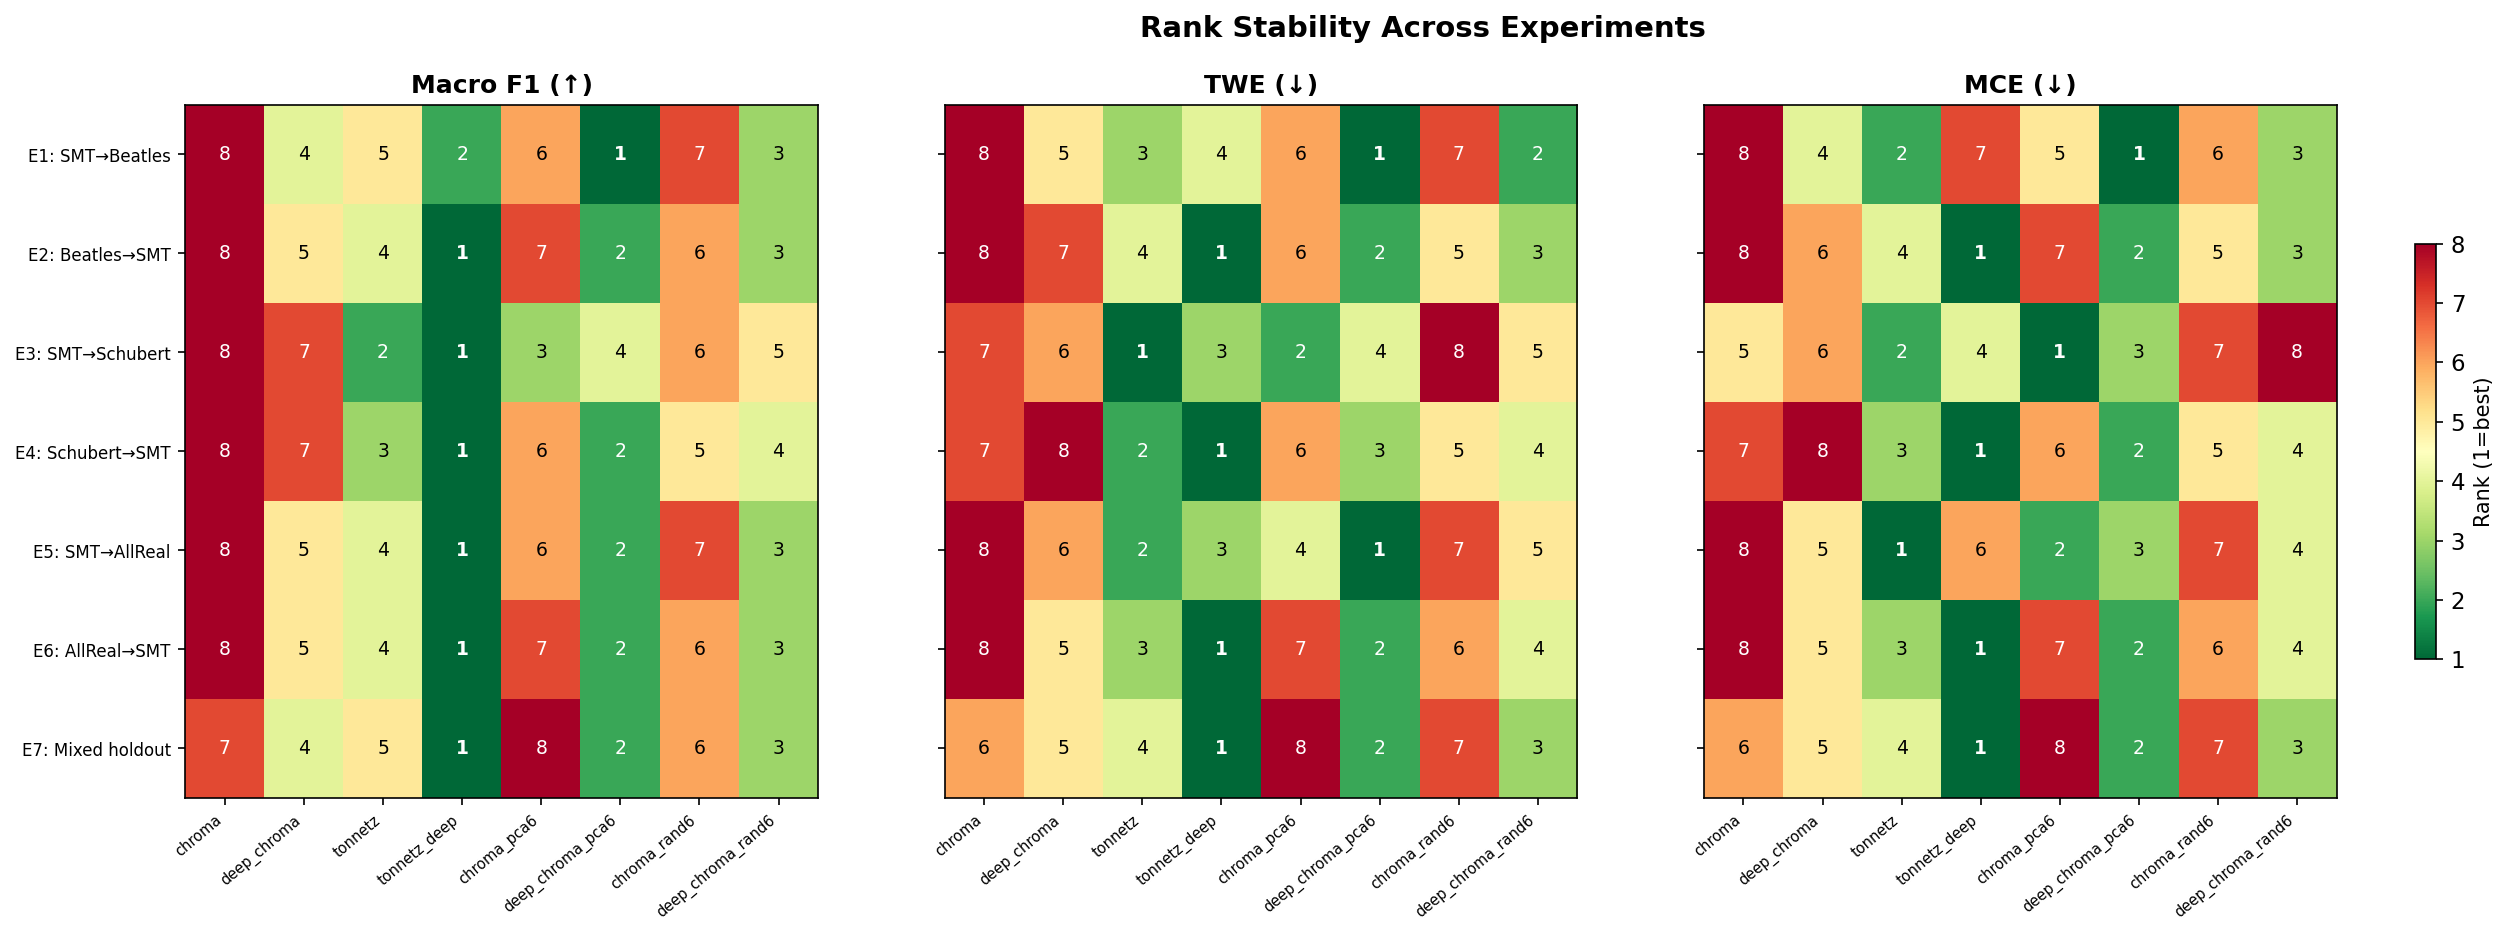

In [3]:
rank_metrics = [
    ('macro_f1', 'Macro F1 (\u2191)', False),
    ('twe',      'TWE (\u2193)',       True),
    ('mce',      'MCE (\u2193)',       True),
]

exp_names = list(all_experiments.keys())
rep_list  = list(ALL_REP_DIMS.keys())

fig, axes = plt.subplots(1, 3, figsize=(22, 6), gridspec_kw={'right': 0.92})

for ax, (metric_key, metric_title, lower_is_better) in zip(axes, rank_metrics):
    rank_matrix = np.zeros((len(exp_names), len(rep_list)))
    for i, (exp_name, exp_res) in enumerate(all_experiments.items()):
        scores = [exp_res[r][metric_key] for r in rep_list]
        if lower_is_better:
            order = np.argsort(scores)
        else:
            order = np.argsort(scores)[::-1]
        ranks = np.zeros(len(rep_list))
        for rank_pos, idx in enumerate(order):
            ranks[idx] = rank_pos + 1
        rank_matrix[i] = ranks

    im = ax.imshow(rank_matrix, cmap='RdYlGn_r', vmin=1, vmax=len(rep_list), aspect='auto')
    ax.set_xticks(range(len(rep_list)))
    ax.set_xticklabels([f'{r}' for r in rep_list], rotation=40, ha='right', fontsize=7)
    ax.set_yticks(range(len(exp_names)))
    ax.set_yticklabels(exp_names if ax == axes[0] else [], fontsize=8)

    for i in range(len(exp_names)):
        for j in range(len(rep_list)):
            rank = int(rank_matrix[i, j])
            color = 'white' if rank <= 2 or rank >= 7 else 'black'
            fontw = 'bold' if rank == 1 else 'normal'
            ax.text(j, i, str(rank), ha='center', va='center',
                    fontsize=9, color=color, fontweight=fontw)

    ax.set_title(metric_title, fontweight='bold')

plt.colorbar(im, ax=axes.tolist(), label='Rank (1=best)', shrink=0.6, pad=0.03)
plt.suptitle('Rank Stability Across Experiments', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## Figure 3 — Winner by Metric × Domain

The optimal representation depends on the target domain. `deep_chroma_pca6` sweeps Beatles; `tonnetz` variants dominate everywhere else.

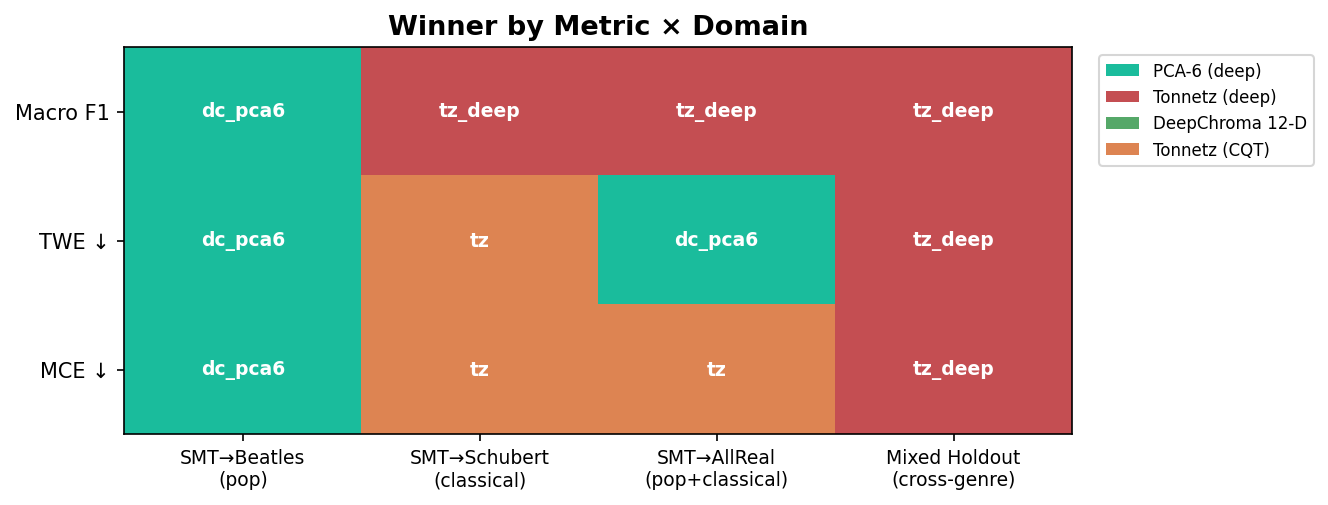

In [4]:
exp_dict = {
    'E1: SMT\u2192Beatles':  results,
    'E3: SMT\u2192Schubert': exp_e3_res,
    'E5: SMT\u2192AllReal':  exp_e5_res,
    'E7: Mixed holdout':     exp_e7_res,
}

# Compute full metrics for focus reps
def compute_full_metrics(preds, targets):
    def _twe(p, t):
        ra, qa = IDX2LABEL[p].split(':'); rb, qb = IDX2LABEL[t].split(':')
        from functools import lru_cache
        ia, ib = ROOTS.index(ra), ROOTS.index(rb)
        # Simplified TWE using interval
        interval = abs(ia - ib) % 12
        return CONSONANCE_VEC[interval] * 0.3 + (0.0 if qa == qb else 0.5)
    acc = (preds == targets).mean()
    macro_f1 = f1_score(targets, preds, average='macro', zero_division=0)
    micro_f1 = f1_score(targets, preds, average='micro', zero_division=0)
    weighted_f1 = f1_score(targets, preds, average='weighted', zero_division=0)
    return dict(acc=acc, macro_f1=macro_f1, micro_f1=micro_f1, weighted_f1=weighted_f1)

# Use stored metrics directly
metric_keys = ['macro_f1', 'twe', 'mce']
metric_names = ['Macro F1', 'TWE \u2193', 'MCE \u2193']
exp_labels = ['SMT\u2192Beatles\n(pop)', 'SMT\u2192Schubert\n(classical)',
              'SMT\u2192AllReal\n(pop+classical)', 'Mixed Holdout\n(cross-genre)']

rep_to_idx = {r: i for i, r in enumerate(focus_reps)}
winner_matrix = np.zeros((len(metric_keys), len(exp_dict)))

for j, exp_name in enumerate(exp_dict):
    exp_res = exp_dict[exp_name]
    for i, m in enumerate(metric_keys):
        if m in ['twe', 'mce']:
            best = min(focus_reps, key=lambda r: exp_res[r][m])
        else:
            best = max(focus_reps, key=lambda r: exp_res[r][m])
        winner_matrix[i, j] = rep_to_idx[best]

fig, ax = plt.subplots(figsize=(9, 3.5))
cmap = matplotlib.colors.ListedColormap([COLORS[r] for r in focus_reps])
im = ax.imshow(winner_matrix, cmap=cmap, vmin=-0.5, vmax=len(focus_reps)-0.5, aspect='auto')

ax.set_xticks(range(len(exp_labels)))
ax.set_xticklabels(exp_labels, fontsize=9)
ax.set_yticks(range(len(metric_names)))
ax.set_yticklabels(metric_names, fontsize=10)

short_names = {r: r.replace('deep_chroma_', 'dc_').replace('tonnetz', 'tz') for r in focus_reps}
for i in range(len(metric_keys)):
    for j in range(len(exp_dict)):
        rep = focus_reps[int(winner_matrix[i, j])]
        ax.text(j, i, short_names[rep], ha='center', va='center',
                fontsize=9, fontweight='bold', color='white')

legend_handles = [Patch(facecolor=COLORS[r], label=fl) for r, fl in zip(focus_reps, focus_labels)]
ax.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8)
ax.set_title('Winner by Metric \u00d7 Domain', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Figure 4 — Error Decomposition Across Experiments

Misclassifications decomposed into root errors, quality errors, and both-wrong. Tonnetz helps roots; DeepChroma helps quality; `tonnetz_deep` combines both.

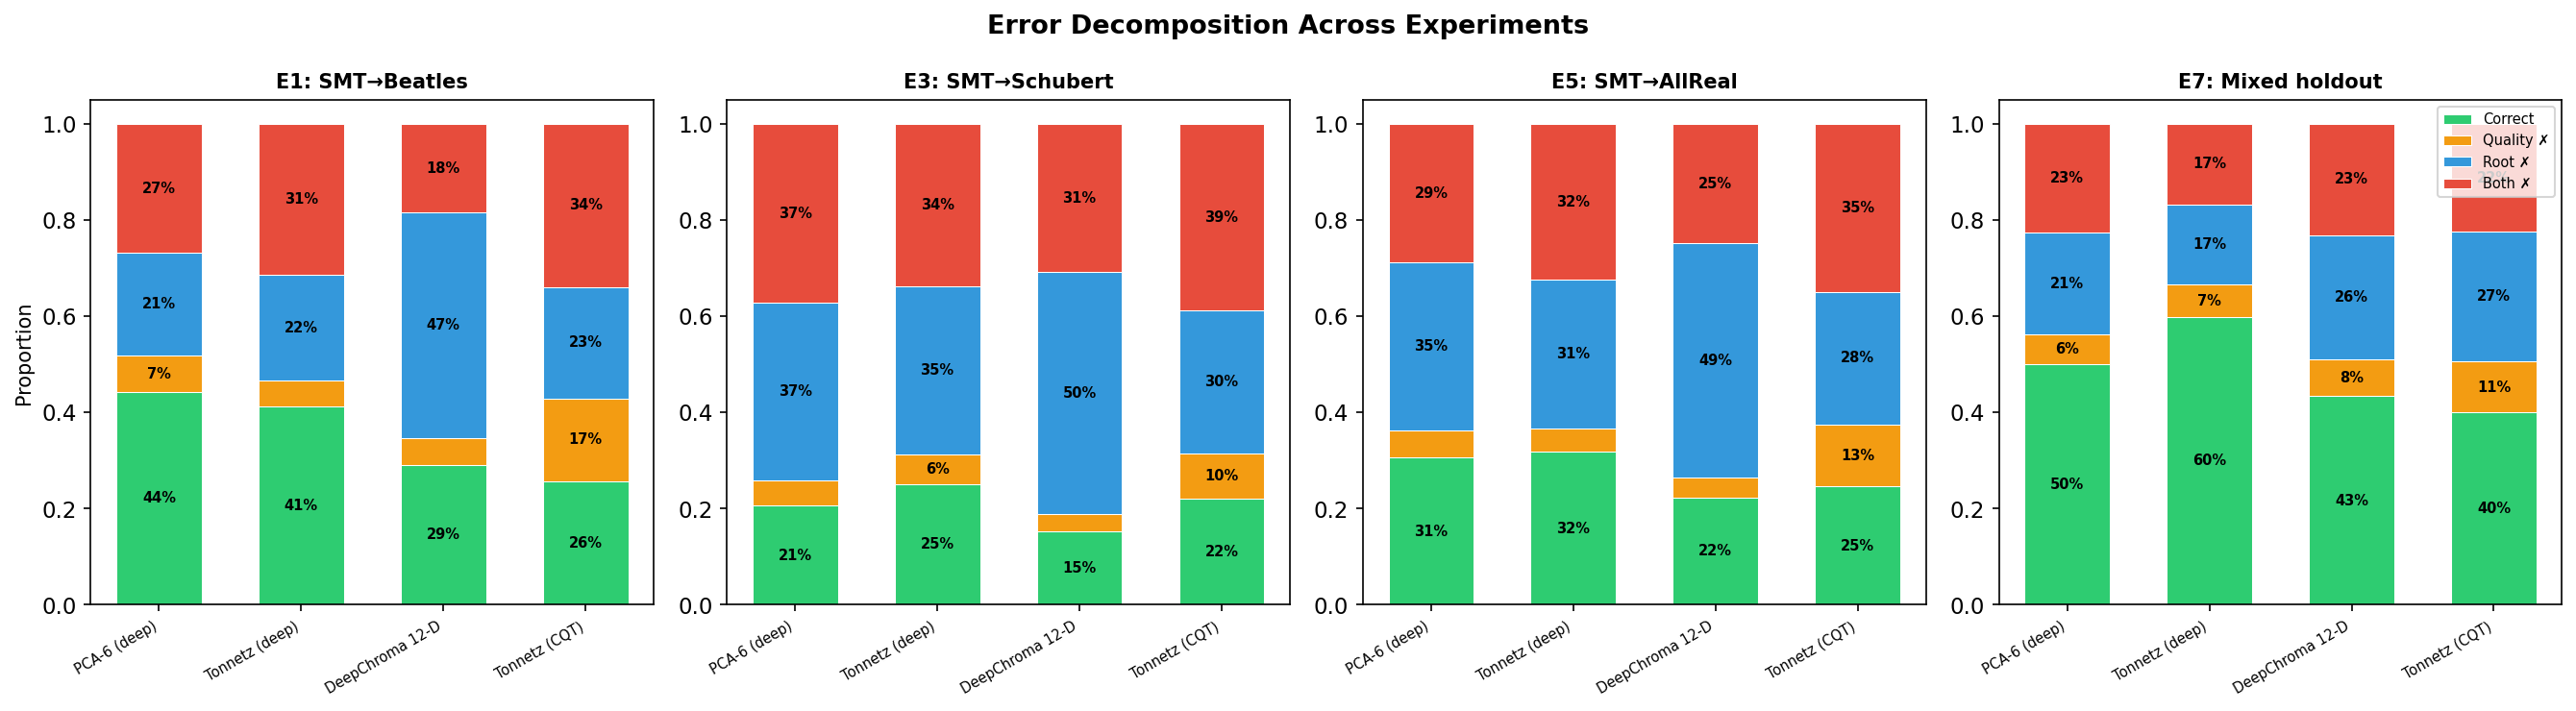

In [5]:
def error_decomposition(preds, targets):
    correct = root_err = qual_err = both_err = 0
    for p, t in zip(preds, targets):
        pr, pq = IDX2LABEL[p].split(':')
        tr, tq = IDX2LABEL[t].split(':')
        if p == t: correct += 1
        elif pr == tr: qual_err += 1
        elif pq == tq: root_err += 1
        else: both_err += 1
    n = len(preds)
    return {'correct': correct/n, 'quality_err': qual_err/n,
            'root_err': root_err/n, 'both_err': both_err/n}

exp_for_decomp = {
    'E1: SMT\u2192Beatles':  results,
    'E3: SMT\u2192Schubert': exp_e3_res,
    'E5: SMT\u2192AllReal':  exp_e5_res,
    'E7: Mixed holdout':     exp_e7_res,
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (exp_name, exp_res) in zip(axes, exp_for_decomp.items()):
    decomps = {r: error_decomposition(exp_res[r]['preds'], exp_res[r]['targets'])
               for r in focus_reps}
    x = np.arange(len(focus_reps))
    w = 0.6
    bottoms = np.zeros(len(focus_reps))

    for key, color, label in [
        ('correct',     '#2ecc71', 'Correct'),
        ('quality_err', '#f39c12', 'Quality \u2717'),
        ('root_err',    '#3498db', 'Root \u2717'),
        ('both_err',    '#e74c3c', 'Both \u2717'),
    ]:
        vals = [decomps[r][key] for r in focus_reps]
        ax.bar(x, vals, w, bottom=bottoms, label=label, color=color,
               edgecolor='white', linewidth=0.5)
        for i, v in enumerate(vals):
            if v > 0.06:
                ax.text(x[i], bottoms[i] + v/2, f'{v:.0%}',
                        ha='center', va='center', fontsize=7, fontweight='bold')
        bottoms += vals

    ax.set_xticks(x)
    ax.set_xticklabels(focus_labels, rotation=30, ha='right', fontsize=7)
    ax.set_ylabel('Proportion' if ax == axes[0] else '')
    ax.set_title(exp_name, fontweight='bold', fontsize=10)
    ax.set_ylim(0, 1.05)
    if ax == axes[-1]:
        ax.legend(loc='upper right', fontsize=7)

plt.suptitle('Error Decomposition Across Experiments', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

## Figure 5 — Random Projection Stability (20 trials × 3 experiments)

Both Tonnetz and PCA are decisively above the random projection distribution (0/20 random draws beat Tonnetz across all experiments). On E7, `chroma_pca6` falls *below* all 20 random draws — PCA actively hurts on cross-genre transfer.

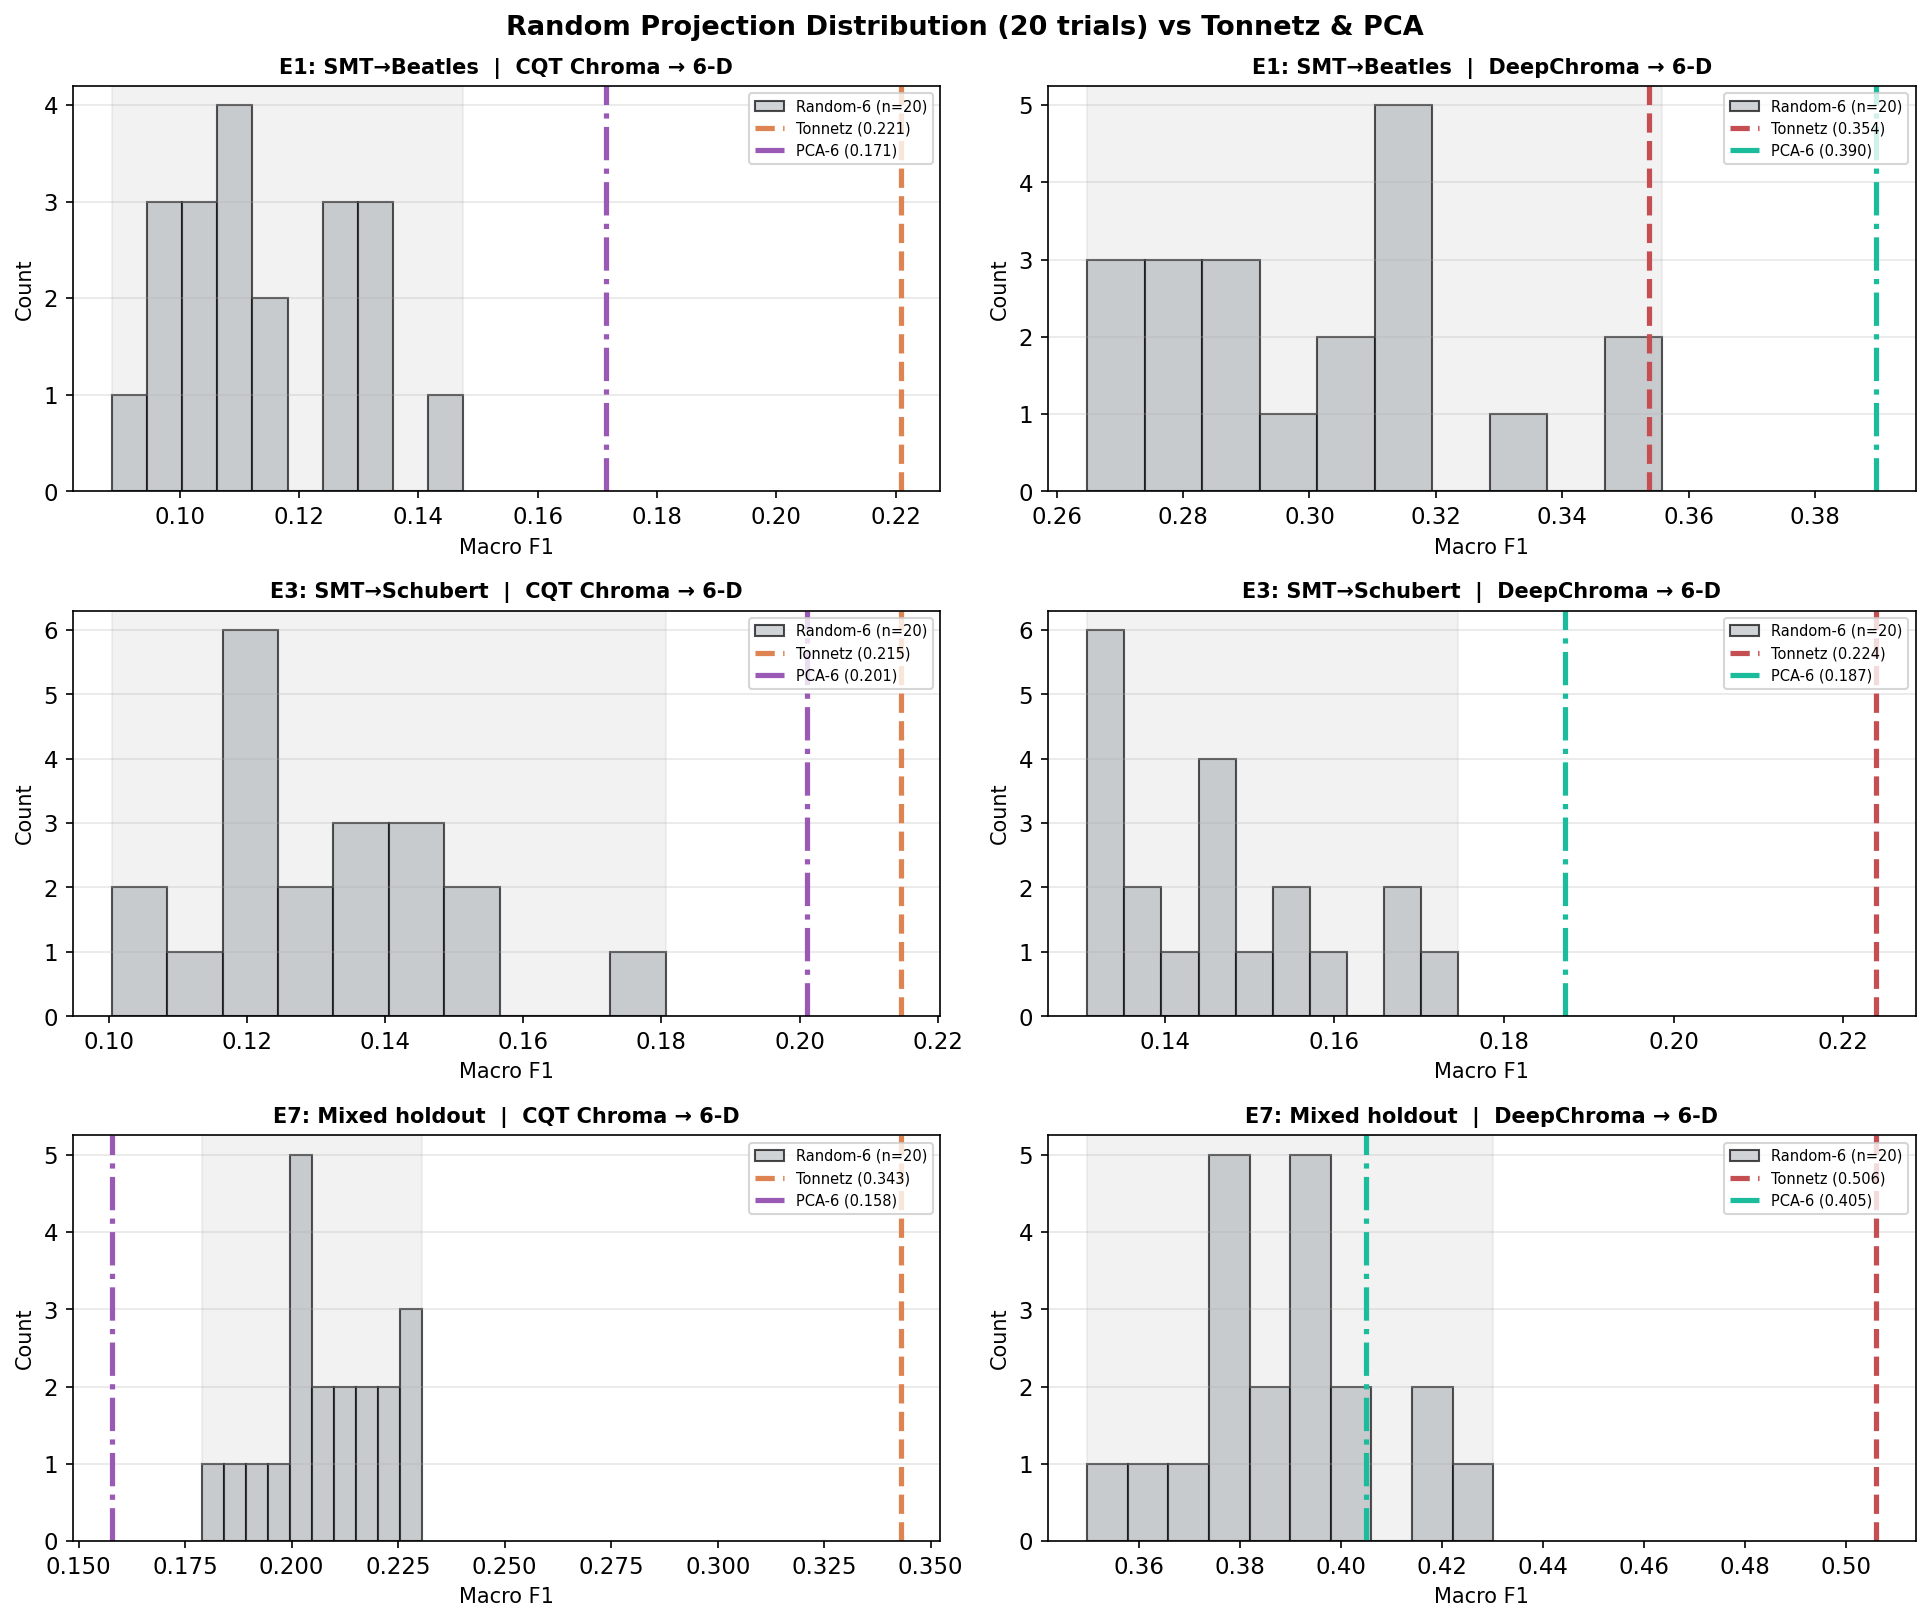

RANDOM PROJECTION STABILITY SUMMARY
Experiment             Chroma         Rand Mean  Rand Std   Tonnetz     PCA-6  #Beat Tz  #Beat PCA
-----------------------------------------------------------------------------------------------
E1: SMT→Beatles        chroma            0.1141    0.0144    0.2209    0.1714      0/20        0/20
E1: SMT→Beatles        deep_chroma       0.3011    0.0249    0.3537    0.3897      1/20        0/20

E3: SMT→Schubert       chroma            0.1312    0.0184    0.2147    0.2011      0/20        0/20
E3: SMT→Schubert       deep_chroma       0.1457    0.0132    0.2239    0.1871      0/20        0/20

E7: Mixed holdout      chroma            0.2084    0.0139    0.3430    0.1578      0/20       20/20
E7: Mixed holdout      deep_chroma       0.3888    0.0186    0.5060    0.4050      0/20        3/20



In [6]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

for row, (exp_name, rand_f1s) in enumerate(rand_results.items()):
    exp_res = ref_values[exp_name]

    for col, (src, src_label) in enumerate([('chroma', 'CQT Chroma'),
                                             ('deep_chroma', 'DeepChroma')]):
        ax = axes[row][col]
        tz_key  = 'tonnetz' if src == 'chroma' else 'tonnetz_deep'
        pca_key = 'chroma_pca6' if src == 'chroma' else 'deep_chroma_pca6'

        tz_f1  = exp_res[tz_key]['macro_f1']
        pca_f1 = exp_res[pca_key]['macro_f1']

        ax.hist(rand_f1s[src], bins=10, color='#BDC3C7', edgecolor='black',
                alpha=0.7, label=f'Random-6 (n=20)')
        ax.axvline(tz_f1, color=COLORS[tz_key], lw=2.5, ls='--',
                   label=f'Tonnetz ({tz_f1:.3f})')
        ax.axvline(pca_f1, color=COLORS[pca_key], lw=2.5, ls='-.',
                   label=f'PCA-6 ({pca_f1:.3f})')
        ax.axvspan(min(rand_f1s[src]), max(rand_f1s[src]), alpha=0.1, color='grey')

        ax.set_xlabel('Macro F1')
        ax.set_ylabel('Count')
        ax.set_title(f'{exp_name}  |  {src_label} \u2192 6-D', fontweight='bold', fontsize=10)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(axis='y', alpha=0.3)

plt.suptitle('Random Projection Distribution (20 trials) vs Tonnetz & PCA',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Summary table
print('RANDOM PROJECTION STABILITY SUMMARY')
print('='*95)
print(f'{"Experiment":<22s} {"Chroma":<14s} {"Rand Mean":>9s} {"Rand Std":>9s} '
      f'{"Tonnetz":>9s} {"PCA-6":>9s} {"#Beat Tz":>9s} {"#Beat PCA":>10s}')
print('-'*95)
for exp_name, rand_f1s in rand_results.items():
    exp_res = ref_values[exp_name]
    for src in ['chroma', 'deep_chroma']:
        tz_key  = 'tonnetz' if src == 'chroma' else 'tonnetz_deep'
        pca_key = 'chroma_pca6' if src == 'chroma' else 'deep_chroma_pca6'
        tz_f1  = exp_res[tz_key]['macro_f1']
        pca_f1 = exp_res[pca_key]['macro_f1']
        r = rand_f1s[src]
        n_tz  = sum(1 for f in r if f > tz_f1)
        n_pca = sum(1 for f in r if f > pca_f1)
        print(f'{exp_name:<22s} {src:<14s} {np.mean(r):9.4f} {np.std(r):9.4f} '
              f'{tz_f1:9.4f} {pca_f1:9.4f} {n_tz:>6d}/20  {n_pca:>7d}/20')
    print()

## Figure 6 — E7 Mixed Holdout: Headline Result

The strongest test: train on SMT + Schubert (pieces 1–12) + Beatles Revolver, test on Schubert (pieces 13–24) + Beatles Sgt Pepper's. `tonnetz_deep` wins every metric by a wide margin.

E7: Mixed Holdout (cross-genre) — All Representations
Model                            Acc  Macro F1   Maj F1   Min F1      TWE      MCE
-------------------------------------------------------------------------------------
CNN-tonnetz_deep               0.599    0.5060   0.6708   0.4928    0.819    1.142 ← BEST
CNN-deep_chroma_pca6           0.501    0.4050   0.5739   0.3923    1.035    1.331
CNN-deep_chroma_rand6          0.483    0.3717   0.5864   0.3007    1.083    1.442
CNN-deep_chroma                0.434    0.3612   0.5233   0.3130    1.189    1.678
CNN-tonnetz                    0.400    0.3430   0.4799   0.3722    1.178    1.578
CNN-chroma_rand6               0.236    0.1909   0.2937   0.1949    1.594    2.102
CNN-chroma                     0.275    0.1892   0.3197   0.1392    1.489    1.944
CNN-chroma_pca6                0.213    0.1578   0.2633   0.1233    1.648    2.252


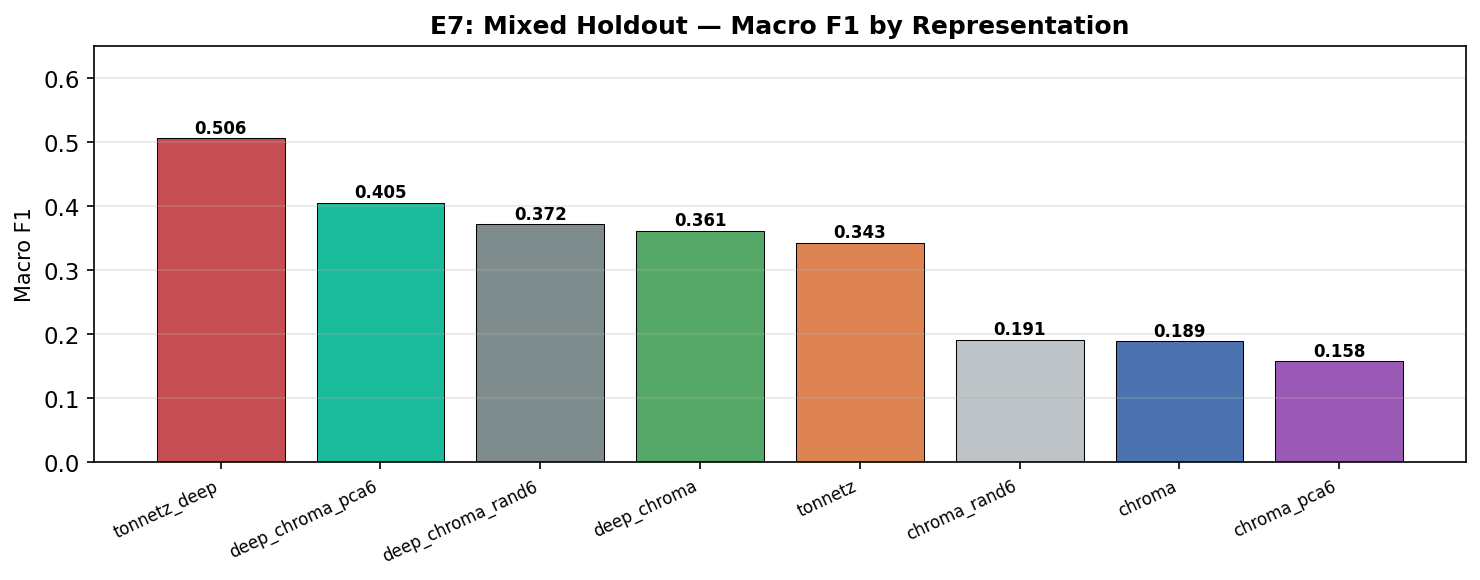

In [9]:
e7 = exp_e7_res
print('E7: Mixed Holdout (cross-genre) — All Representations')
print('='*85)
print(f'{"Model":<28s} {"Acc":>7s} {"Macro F1":>9s} {"Maj F1":>8s} {"Min F1":>8s} {"TWE":>8s} {"MCE":>8s}')
print('-'*85)

sorted_reps = sorted(ALL_REP_DIMS.keys(), key=lambda r: e7[r]['macro_f1'], reverse=True)
for rep in sorted_reps:
    m = e7[rep]
    marker = ' \u2190 BEST' if rep == sorted_reps[0] else ''
    print(f'CNN-{rep:<24s} {m["acc"]:7.3f} {m["macro_f1"]:9.4f} {m["maj_f1"]:8.4f} '
          f'{m["min_f1"]:8.4f} {m["twe"]:8.3f} {m["mce"]:8.3f}{marker}')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(sorted_reps))
vals = [e7[r]['macro_f1'] for r in sorted_reps]
bars = ax.bar(x, vals, color=[COLORS[r] for r in sorted_reps],
              edgecolor='black', linewidth=0.5)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.008, f'{v:.3f}',
            ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f'{r}' for r in sorted_reps], rotation=25, ha='right', fontsize=8)
ax.set_ylabel('Macro F1')
ax.set_title('E7: Mixed Holdout — Macro F1 by Representation', fontweight='bold')
ax.set_ylim(0, 0.65)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Finding | Evidence |
|---|---|
| `tonnetz_deep` wins 6/7 experiments on Macro F1 | Rank stability heatmap (Fig. 2) |
| `deep_chroma_pca6` wins only on Beatles (diatonic pop) | Winner heatmap (Fig. 3) |
| Tonnetz helps root discrimination; DeepChroma helps quality | Error decomposition (Fig. 4) |
| Neither Tonnetz nor PCA is a lucky random draw | 0/120 random projections beat Tonnetz (Fig. 5) |
| PCA actively hurts on cross-genre transfer | 20/20 random draws beat `chroma_pca6` on E7 (Fig. 5) |
| `tonnetz_deep` leads E7 by ~10pp Macro F1 | E7 table (Fig. 6): 0.506 vs 0.405 |

**Conclusion:** The optimal representation depends on harmonic complexity. For diatonic pop, PCA on DeepChroma suffices. For chromatic classical music and cross-genre generalisation, the Tonnetz geometry provides a measurable advantage.